# 조류 조기경보 — 탐색적 데이터 분석 (F3)

국립환경과학원 조류경보제 측정자료(2015~2025)를 대상으로 유해남조류 세포수의 **분포·계절성·지점차이·시간구조·수질변수 상관**을 살핀다.

- **범위:** 조류 중심. 외생변수(기상) 상관은 지점 좌표↔ASOS 관측소 매칭 확보 후 별도 추가.
- **목적:** F4(피처 엔지니어링) 설계 근거 + 대회 산출물.
- **재현:** `uv run python -m src.eda` → `reports/figures/*.png` (이 노트북은 동일 함수를 호출).

선행 산출물: F2 감사 `reports/f2_audit.md`, 타깃 `src/target.py`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# 저장소 루트를 찾아 import 경로에 추가 (실행 위치 무관)
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "eda.py").exists())
sys.path.insert(0, str(root))

from src import eda

eda.setup_style()
df = eda.load_clean()
print(f"rows={len(df):,}  sites={df['site_code'].nunique()}  "
      f"기간 {df['date'].min().date()} ~ {df['date'].max().date()}")
df[["site_code", "site_name", "date", "cyano_cells", "station_type", "major_basin"]].head()

rows=39,317  sites=72  기간 2014-12-29 ~ 2026-06-25


,site_code,site_name,date,cyano_cells,station_type,major_basin
0,1003G20,충주호,2015-03-23,0.0,호소,한강
1,1003G20,충주호,2015-03-30,0.0,호소,한강
2,1003G20,충주호,2015-04-06,0.0,호소,한강
3,1003G20,충주호,2015-04-13,0.0,호소,한강
4,1003G20,충주호,2015-04-20,0.0,호소,한강


## 1. 타깃 분포 — 유해남조류 세포수

제로팽창(대부분 0) + 극단적 롱테일. 값 예측(회귀)보다 **임계 초과 이진 분류**가 타당한 이유. 임계선(관심 1,000 / 경계 10,000) 표시.

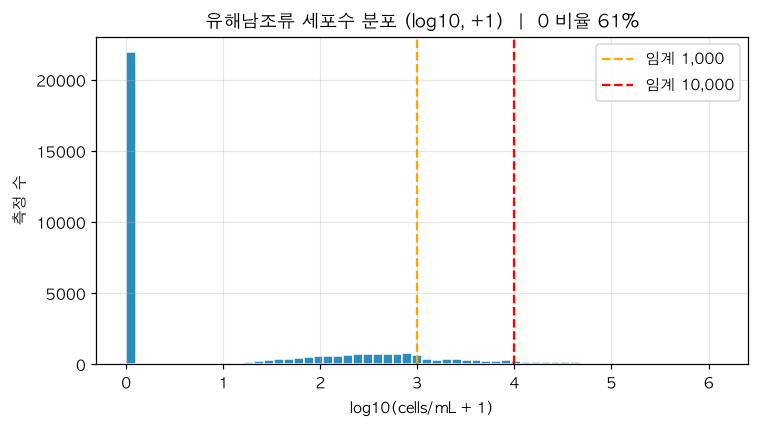

In [2]:
eda.fig_cyano_distribution(df);

## 2. 계절성 — 월별

여름(6~9월)에 초과율 급증. 겨울엔 거의 0. → **월/주차/조류시즌 피처 필수**, 시간순 검증에서 계절 분포 고려.

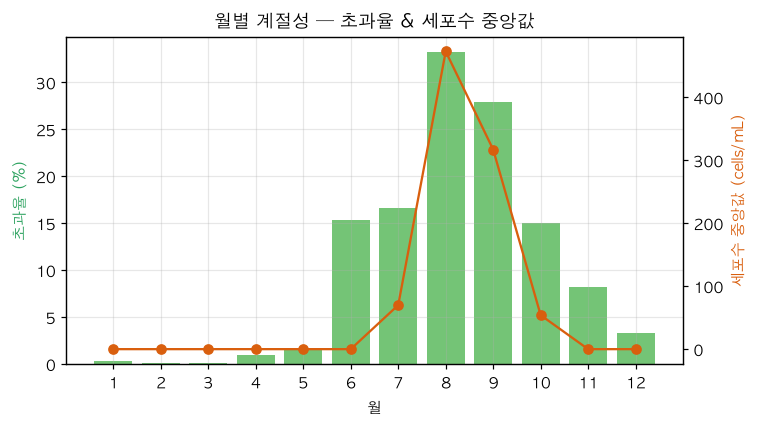

In [3]:
eda.fig_monthly_seasonality(df);

## 3. 지점·권역 차이

대권역/지점별 초과율 편차가 큼. → `site`를 범주형으로 두고, **글로벌 통합 모델 vs 지점별 모델**을 비교(§8.1).

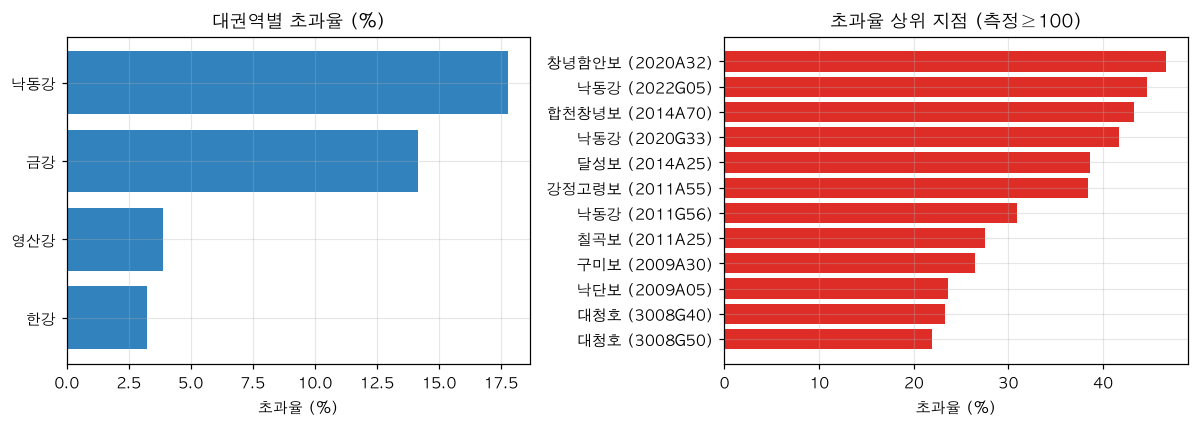

In [4]:
eda.fig_basin_exceedance(df);

## 4. 지속성·자기상관

직전 측정이 다음 측정을 강하게 예측(persistence). lag별 자기상관 감쇠 확인. → **lag 피처(특히 lag1)가 핵심**이고, persistence 베이스라인이 강력한 경쟁자.

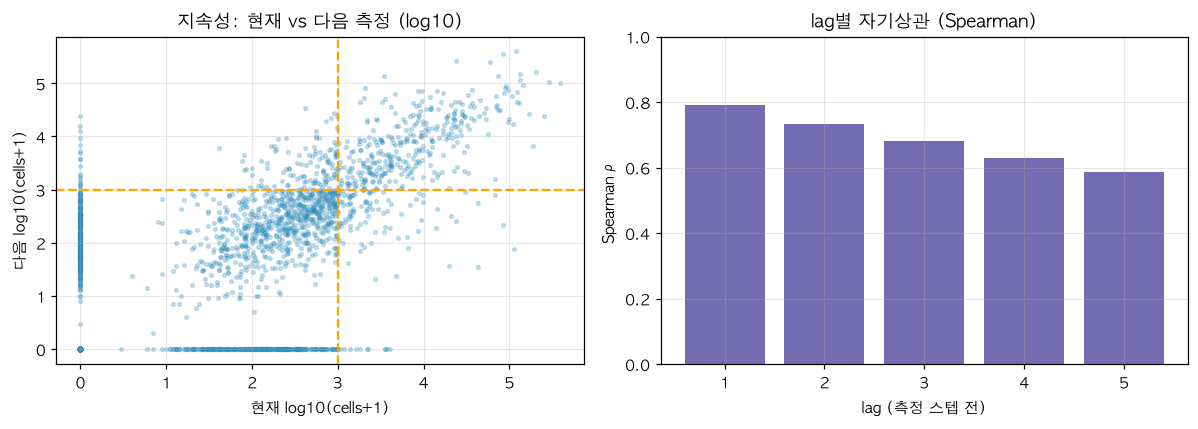

In [5]:
eda.fig_persistence_autocorr(df);

## 5. 수질변수 상관 (Spearman)

세포수와의 상관 크기 순으로 피처 우선순위. **수온**이 가장 강함.

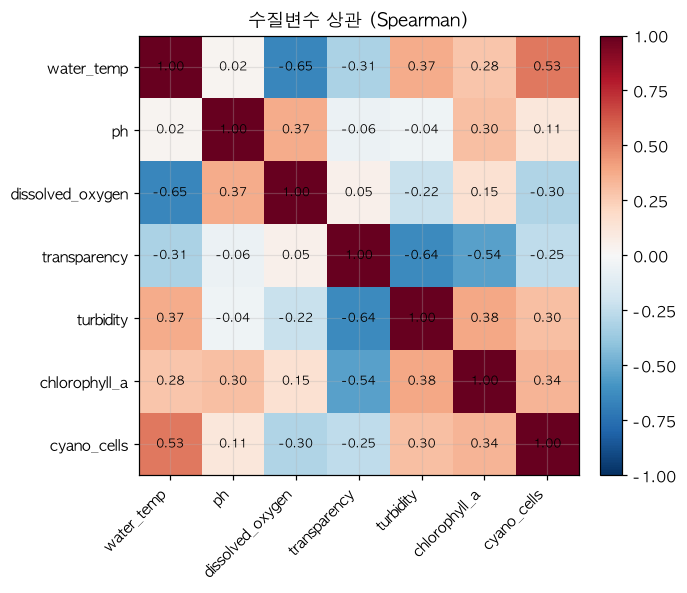

In [6]:
eda.fig_waterquality_corr(df);

## 6. 연도별 추세

연도별 초과율 변동. → **연도 홀드아웃 시간순 검증**의 타당성(연도 간 분포 차이).

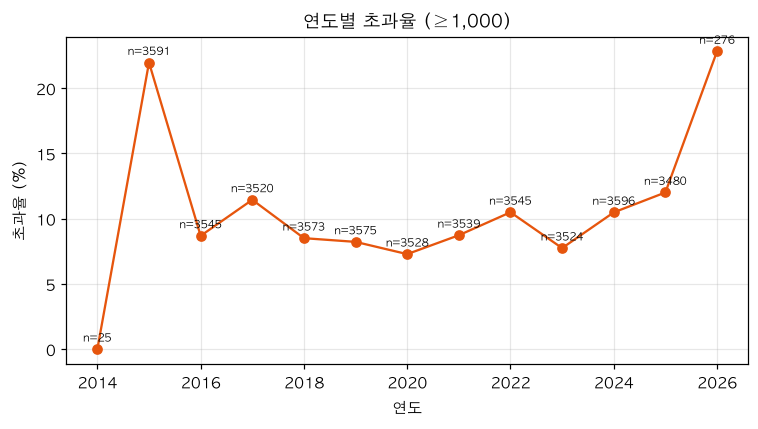

In [7]:
eda.fig_yearly_trend(df);

## 결론 → F4 피처 설계 시사점

1. **제로팽창 + 롱테일** → 이진 임계(1,000) 프레이밍 타당(회귀는 후순위).
2. **강한 계절성**(8월 피크 ~33%, 겨울 <1%) → 월/주차/조류시즌·(가능시)누적수온 피처.
3. **강한 persistence**(lag1 Spearman ρ≈0.79, lag5까지 ~0.59) → 세포수 lag/rolling이 핵심 피처, persistence 베이스라인 필수 비교.
4. **수온이 최강 수질 상관**(ρ≈0.53), 이어 클로로필·탁도 → 이 변수들의 현재값 + lag 우선.
5. **지점/권역 이질성** → `site` 범주형 + 글로벌/지점별 모델 비교, 미지 지점 일반화 검증.
6. **연도별 변동** → 연도 홀드아웃 시간순 CV.

누수 방지(§8.3): 모든 lag/rolling은 `groupby('site')` → 시간정렬 → `shift(1)` 이후 계산. 라벨 생성 측정치(다음 측정)는 피처로 재사용 금지(`src/target.py` 참조).